### 🎨 Objetivo del Código: Transferencia de Estilo 🖼️

El objetivo de este código es realizar la **transferencia de estilo** entre una imagen de contenido y una imagen de estilo optmizando esto con DL. La transferencia de estilo implica combinar el **contenido** de una imagen de contenido con el **estilo visual** de una imagen de estilo para crear una nueva imagen que conserve el contenido de la imagen de contenido pero tenga el estilo de la imagen de estilo. Este proceso se realiza utilizando una **red neuronal convolucional (CNN)** pre-entrenada para extraer características tanto del contenido como del estilo de las imágenes.

Luego, se optimiza una **imagen de entrada** para minimizar las diferencias entre las características de estilo y contenido extraídas de la imagen de entrada y las imágenes de estilo y contenido originales. El resultado es una nueva imagen que presenta el contenido deseado con el estilo de la imagen de estilo.

El código utiliza una serie de funciones y clases para construir un modelo de transferencia de estilo, calcular las pérdidas de estilo y contenido, y optimizar la imagen de entrada para lograr el efecto deseado. Finalmente, muestra la imagen resultante, que representa la combinación de contenido y estilo. 🚀


In [ ]:
# Habilita la funcionalidad de la función de impresión de Python 3 en Python 2.(opcional y para su conocimiento)
from __future__ import print_function

# Importa la biblioteca principal de PyTorch.
import torch

# Importa el módulo nn (neural networks) de PyTorch, que contiene herramientas para construir y entrenar redes neuronales.
import torch.nn as nn

# Importa el módulo F de PyTorch, que contiene funciones de activación y funciones útiles para el procesamiento de tensores.
import torch.nn.functional as F

# Importa el módulo optim de PyTorch, que contiene optimizadores para actualizar los pesos de la red neuronal durante el entrenamiento.
import torch.optim as optim

# Importa la clase Image del módulo PIL (Python Imaging Library), que se utiliza para manipular imágenes en Python.
from PIL import Image

# Importa la biblioteca matplotlib.pyplot, que se utiliza para trazar y visualizar datos en forma de gráficos y figuras.
import matplotlib.pyplot as plt

# Importa el módulo transforms de torchvision, que proporciona utilidades para transformar imágenes y tensores.
import torchvision.transforms as transforms

# Importa el módulo models de torchvision, que contiene modelos preentrenados para tareas de visión por computadora.
import torchvision.models as models

# Importa la función copy, que se utiliza para crear copias de objetos en Python.
import copy

# Esta es una "magic function" en Jupyter Notebook que indica a la interfaz de trazado de matplotlib que muestre las figuras dentro del cuaderno en lugar de abrir una ventana emergente.
%matplotlib inline


In [ ]:
# Verifica si CUDA (una arquitectura de procesamiento paralelo de GPU de NVIDIA) está disponible en el sistema.
# Si CUDA está disponible, el dispositivo se establece en "cuda"; de lo contrario, se establece en "cpu".



In [ ]:
# Descarga la imagen desde la URL especificada y la guarda con el nombre "paris.jpg".
!wget "https://i.imgur.com/F28w3Ac.jpg" -O "paris.jpg"

# Descarga la imagen desde la URL especificada y la guarda con el nombre "starry_night.jpg".
!wget "https://i.imgur.com/9ooB60I.jpg" -O "starry_night.jpg"


--2024-02-14 18:31:08--  https://i.imgur.com/F28w3Ac.jpg
Resolving i.imgur.com (i.imgur.com)... 146.75.80.193
Connecting to i.imgur.com (i.imgur.com)|146.75.80.193|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 102437 (100K) [image/jpeg]
Saving to: ‘paris.jpg’

paris.jpg           100%[===================>] 100.04K  --.-KB/s    in 0.02s   

2024-02-14 18:31:08 (4.70 MB/s) - ‘paris.jpg’ saved [102437/102437]

--2024-02-14 18:31:08--  https://i.imgur.com/9ooB60I.jpg
Resolving i.imgur.com (i.imgur.com)... 146.75.80.193
Connecting to i.imgur.com (i.imgur.com)|146.75.80.193|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 935806 (914K) [image/jpeg]
Saving to: ‘starry_night.jpg’

starry_night.jpg    100%[===================>] 913.87K  --.-KB/s    in 0.05s   

2024-02-14 18:31:08 (16.7 MB/s) - ‘starry_night.jpg’ saved [935806/935806]



In [ ]:
# Tamaño deseado de la imagen de salida.
# Se establece en 512 si CUDA está disponible (para aprovechar una GPU); de lo contrario, se establece en 128 para una ejecución más rápida en la CPU.
imsize = 512 if torch.cuda.is_available() else 128

# Se define una secuencia de transformaciones para aplicar a las imágenes.
# En este caso, se redimensiona la imagen al tamaño especificado en 'imsize' y se convierte en un tensor de PyTorch.

      # Escala la imagen importada al tamaño especificado
     # Transforma la imagen en un tensor de PyTorch

# Función para cargar una imagen desde el disco y aplicar las transformaciones definidas anteriormente.

    # Abre la imagen desde el disco.

    # Redimensiona la imagen al tamaño deseado.
    # Aquí se ajusta la altura para mantener la relación de aspecto original (128/191).

    # Aplica las transformaciones definidas anteriormente y agrega una dimensión adicional al tensor.

    # Mueve el tensor al dispositivo (GPU si está disponible, de lo contrario CPU) y lo convierte en un tipo de datos de punto flotante.


# Carga las imágenes de estilo y contenido utilizando la función 'image_loader'.
style_img = image_loader("./starry_night.jpg")  # Carga la imagen de estilo (La noche estrellada).
content_img = image_loader("./paris.jpg")  # Carga la imagen de contenido (París).

# Asegura que las imágenes de estilo y contenido tengan el mismo tamaño.



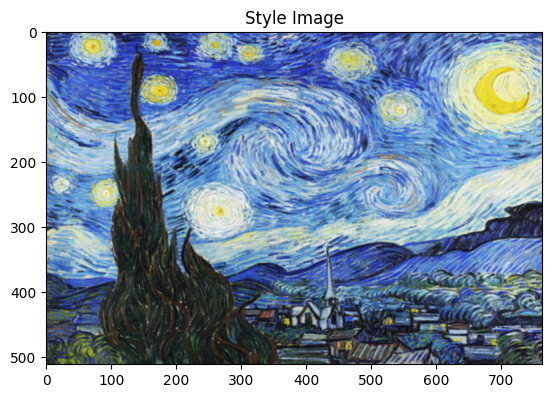

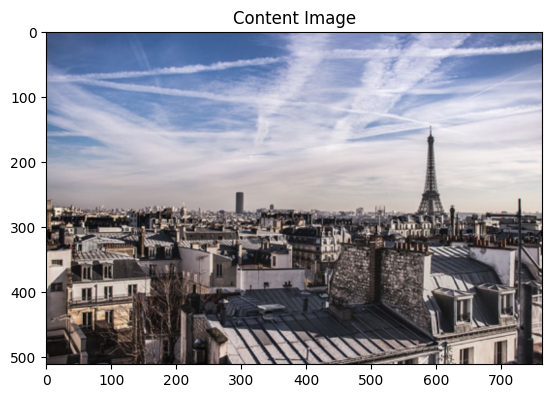

In [ ]:
# Define una transformación para convertir un tensor de PyTorch de nuevo a una imagen PIL.

# Activa el modo interactivo para que las figuras se muestren de inmediato.


# Función para mostrar una imagen representada como un tensor de PyTorch.

    # Clona el tensor para evitar cambios en el original.

    # Elimina la dimensión de lote artificial.

    # Convierte el tensor en una imagen PIL.

    # Muestra la imagen utilizando matplotlib.

    # Agrega un título a la imagen si se proporciona.

    # Pausa brevemente para que se actualicen los gráficos.


# Crea una nueva figura y muestra la imagen de estilo.


# Crea otra figura y muestra la imagen de contenido.



In [ ]:
# Definición de una clase ContentLoss que hereda de nn.Module.


    # Constructor de la clase ContentLoss.

        # 'target' representa el contenido deseado que queremos que la red reproduzca.
        # Usamos 'detach' para separar el contenido objetivo de la estructura de cálculo dinámico de gradientes.
        # Esto significa que el contenido objetivo es un valor fijo, no una variable que requiere cálculo de gradiente.


    # Método 'forward' que define la operación de reenvío (forward) de la capa ContentLoss.

        # Calcula la pérdida de contenido como el error cuadrático medio (MSE) entre la entrada y el contenido objetivo.

        # Retorna la entrada sin modificar, ya que la pérdida se calcula en el método forward.


In [ ]:
# Definición de una función para calcular la matriz de Gram de una capa de características.

    # Obtiene las dimensiones de la entrada.
                               # a=tamaño del lote(=1)
                               # b=número de mapas de características
                               # (c,d)=dimensiones de un mapa de características (N=c*d)

    # Reorganiza la entrada para que cada mapa de características sea un vector de características.
                        # Redimensiona la matriz de características para que tenga una forma adecuada para el cálculo de la matriz de Gram.

    # Calcula el producto de la matriz de características reorganizada por su traspuesta.
                              # Computa el producto de Gram.

    # Normaliza los valores de la matriz de Gram dividiendo por el número de elementos en cada mapa de características.



In [ ]:
# Definición de una clase StyleLoss que hereda de nn.Module.


    # Constructor de la clase StyleLoss.

        # Calcula y almacena la matriz de Gram del objetivo de estilo.
        # Utiliza 'detach' para separarla de la estructura de cálculo dinámico de gradientes.


    # Método 'forward' que define la operación de reenvío (forward) de la capa StyleLoss.

        # Calcula la matriz de Gram de la entrada.

        # Calcula la pérdida de estilo como el error cuadrático medio (MSE) entre la matriz de Gram de la entrada y la matriz de Gram del objetivo de estilo.

        # Retorna la entrada sin modificar, ya que la pérdida se calcula en el método forward.



In [ ]:
# Carga del modelo pre-entrenado VGG19 y lo mueve al dispositivo de computación (GPU si está disponible).



In [ ]:
# Define los valores de media y desviación estándar utilizados para normalizar las imágenes de entrada.


# Crea un módulo para normalizar la imagen de entrada para que pueda ser fácilmente insertada en una secuencia nn.Sequential.

        # Reorganiza la media y la desviación estándar para que tengan la forma [C x 1 x 1],
        # de modo que puedan funcionar directamente con tensores de imagen de forma [B x C x H x W].
        # B es el tamaño del lote. C es el número de canales. H es la altura y W es el ancho.


        # Normaliza la imagen restando la media y dividiendo por la desviación estándar.



In [ ]:
# Capas por defecto utilizadas para calcular las pérdidas de estilo/contenido.

# Función para obtener el modelo y las pérdidas de estilo/contenido.

    # Módulo de normalización.

    # Lista para almacenar las pérdidas de contenido y estilo.

    # Creamos un nuevo Sequential para poner los módulos que se deben activar secuencialmente.


                # Incrementa cada vez que encontramos una capa convolucional.


            # La versión in-place no funciona muy bien con ContentLoss y StyleLoss.
            # Así que la reemplazamos por versiones out-of-place.

        # Agregamos la capa al modelo.


    # Recortamos las capas después de las últimas pérdidas de estilo/contenido.



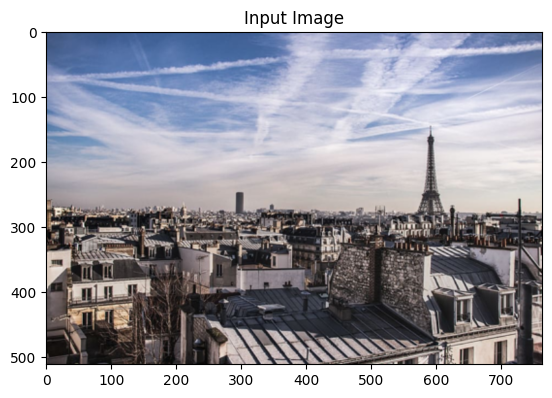

In [ ]:
# Clona la imagen de contenido para usarla como la imagen de entrada inicial.

# Si deseas usar ruido blanco en su lugar, descomenta la siguiente línea:
# input_img = torch.randn(content_img.data.size(), device=device)

# Crea una nueva figura para mostrar la imagen de entrada.

# Muestra la imagen de entrada en la figura.



In [ ]:
# Definición de una función para obtener un optimizador para la imagen de entrada.

    # Indica que la imagen de entrada es un parámetro que requiere un gradiente.
    # Se utiliza el algoritmo de optimización L-BFGS para optimizar la imagen de entrada.


In [ ]:
# Definición de la función para realizar la transferencia de estilo.

    # Construye el modelo de transferencia de estilo y obtiene las pérdidas de estilo y contenido.

    # Queremos optimizar la imagen de entrada y no los parámetros del modelo, así que
    # actualizamos todos los campos requires_grad en consecuencia.

    # Obtiene el optimizador para la imagen de entrada.


            # Corrige los valores de la imagen de entrada actualizada.

            # Reinicia los gradientes del optimizador.

            # Ejecuta el modelo para la imagen de entrada.

            # Calcula las pérdidas de estilo y contenido.

            # Aplica los pesos de estilo y contenido a sus respectivas pérdidas.

            # Calcula la pérdida total como la suma ponderada de la pérdida de estilo y la pérdida de contenido.

            # Calcula los gradientes de la pérdida total.


            # Incrementa el contador de pasos.

                # Imprime las pérdidas de estilo y contenido cada 50 pasos.



        # Realiza un paso de optimización.

    # Realiza una última corrección...


    # Retorna la imagen de entrada después de la transferencia de estilo.


Construyendo el modelo de transferencia de estilo..


<ipython-input-11-719cdd36a4b7>:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(mean).view(-1, 1, 1)
<ipython-input-11-719cdd36a4b7>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(std).view(-1, 1, 1)


Optimizando..
paso [50]:
Pérdida de estilo: 41.696854 Pérdida de contenido: 56.006771

paso [100]:
Pérdida de estilo: 22.611198 Pérdida de contenido: 45.559971

paso [150]:
Pérdida de estilo: 7.839592 Pérdida de contenido: 38.798023

paso [200]:
Pérdida de estilo: 5.409926 Pérdida de contenido: 34.477707

paso [250]:
Pérdida de estilo: 4.166827 Pérdida de contenido: 31.960005

paso [300]:
Pérdida de estilo: 3.337941 Pérdida de contenido: 30.208458



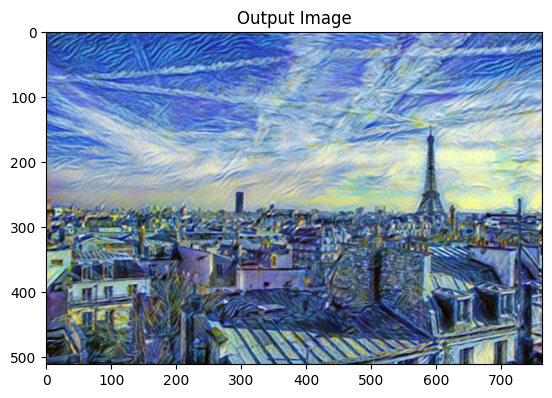

In [ ]:
# Ejecuta la transferencia de estilo para obtener la imagen de salida.


# Crea una nueva figura para mostrar la imagen de salida.

# Muestra la imagen de salida en la figura.


# Desactiva el modo interactivo de matplotlib.

# Muestra la figura.
